In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
data=pd.read_csv('../dataset/all-data.csv',encoding='latin-1',header=None)
data.head()

,0,1
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [3]:
print(data.shape)

(4846, 2)


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       4846 non-null   str  
 1   1       4846 non-null   str  
dtypes: str(2)
memory usage: 717.4 KB


In [5]:
print(data.columns)

Index([0, 1], dtype='int64')


In [6]:
data.columns=['sentimental','news']

In [7]:
data.head()

,sentimental,news
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [8]:
print(data.columns)

Index(['sentimental', 'news'], dtype='str')


In [9]:
print(data['sentimental'].value_counts())

sentimental
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


In [10]:
print(data.isnull().sum())

sentimental    0
news           0
dtype: int64


In [11]:
print(data.duplicated().sum() )

6


In [12]:
data.drop_duplicates(inplace=True)

In [13]:
print(data.duplicated().sum() )

0


In [14]:
data['length']=data['news'].apply(len)
print(data['length'].describe())

count    4840.000000
mean      128.076446
std        56.416479
min         9.000000
25%        84.000000
50%       119.000000
75%       163.000000
max       315.000000
Name: length, dtype: float64


In [15]:
data.head()

,sentimental,news,length
0,neutral,"According to Gran , the company has no plans t...",127
1,neutral,Technopolis plans to develop in stages an area...,190
2,negative,The international electronic industry company ...,228
3,positive,With the new production plant the company woul...,206
4,positive,According to the company 's updated strategy f...,203


In [16]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omnw-1.4')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Error loading omnw-1.4: Package 'omnw-1.4' not found in
[nltk_data]     index


In [17]:
data.drop('length',axis=1,inplace=True)

In [18]:
data.head()

,sentimental,news
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [19]:
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words=text.split()
    words=[lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return "   ".join(words)

data['cleaned_news']=data['news'].apply(preprocess_text)
data

,sentimental,news,cleaned_news
0,neutral,"According to Gran , the company has no plans t...",according gran company plan move pro...
1,neutral,Technopolis plans to develop in stages an area...,technopolis plan develop stage area ...
2,negative,The international electronic industry company ...,international electronic industry compan...
3,positive,With the new production plant the company woul...,new production plant company would i...
4,positive,According to the company 's updated strategy f...,according company updated strategy yea...
...,...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...,london marketwatch share price ended ...
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,rinkuskiai beer sale fell per cent ...
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...,operating profit fell eur mn eur m...
4844,negative,Net sales of the Paper segment decreased to EU...,net sale paper segment decreased eur...


In [20]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data['label']=label_encoder.fit_transform(data['sentimental'])
data.head()

,sentimental,news,cleaned_news,label
0,neutral,"According to Gran , the company has no plans t...",according gran company plan move pro...,1
1,neutral,Technopolis plans to develop in stages an area...,technopolis plan develop stage area ...,1
2,negative,The international electronic industry company ...,international electronic industry compan...,0
3,positive,With the new production plant the company woul...,new production plant company would i...,2
4,positive,According to the company 's updated strategy f...,according company updated strategy yea...,2


In [21]:
from sklearn.model_selection import train_test_split
X=data['cleaned_news']
y=data['label']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=10000,ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [23]:
X_train_tfidf.shape

(3872, 10000)

In [24]:
X_train_tfidf.shape
print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 56365 stored elements and shape (3872, 10000)>
  Coords	Values
  (0, 7091)	0.14600958975920802
  (0, 8163)	0.18099339782653126
  (0, 8694)	0.6041813306026458
  (0, 6228)	0.17036864707775407
  (0, 4592)	0.21603909667467797
  (0, 6639)	0.28334840240688997
  (0, 9941)	0.1427129815803531
  (0, 7713)	0.1338837538299904
  (0, 7097)	0.25687942668498914
  (0, 8695)	0.31312566949137755
  (0, 6230)	0.21099324400789862
  (0, 4615)	0.28787132276684796
  (0, 6660)	0.23848380367996394
  (0, 7719)	0.19573878905661057
  (1, 8278)	0.24186788113825505
  (1, 7902)	0.31528228671127734
  (1, 5062)	0.26575010542433597
  (1, 3553)	0.2731658740970101
  (1, 5526)	0.2947191212550641
  (1, 6415)	0.18971894943505374
  (1, 9808)	0.30926102935755134
  (1, 7903)	0.3927079540195077
  (1, 5065)	0.3927079540195077
  (1, 3561)	0.41221377423347244
  (2, 9563)	0.529046585883605
  :	:
  (3871, 4613)	0.1258868118733716
  (3871, 1375)	0.19760396776174396
  (3871, 

In [25]:
print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 56365 stored elements and shape (3872, 10000)>
  Coords	Values
  (0, 7091)	0.14600958975920802
  (0, 8163)	0.18099339782653126
  (0, 8694)	0.6041813306026458
  (0, 6228)	0.17036864707775407
  (0, 4592)	0.21603909667467797
  (0, 6639)	0.28334840240688997
  (0, 9941)	0.1427129815803531
  (0, 7713)	0.1338837538299904
  (0, 7097)	0.25687942668498914
  (0, 8695)	0.31312566949137755
  (0, 6230)	0.21099324400789862
  (0, 4615)	0.28787132276684796
  (0, 6660)	0.23848380367996394
  (0, 7719)	0.19573878905661057
  (1, 8278)	0.24186788113825505
  (1, 7902)	0.31528228671127734
  (1, 5062)	0.26575010542433597
  (1, 3553)	0.2731658740970101
  (1, 5526)	0.2947191212550641
  (1, 6415)	0.18971894943505374
  (1, 9808)	0.30926102935755134
  (1, 7903)	0.3927079540195077
  (1, 5065)	0.3927079540195077
  (1, 3561)	0.41221377423347244
  (2, 9563)	0.529046585883605
  :	:
  (3871, 4613)	0.1258868118733716
  (3871, 1375)	0.19760396776174396
  (3871, 

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = {}
trainded_models = {}

for name, model in models.items():
    
    # Train
    model.fit(X_train_tfidf, y_train)
    
    trainded_models[name] = model
    
    # Predict
    y_pred = model.predict(X_test_tfidf)
    
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    results[name] = accuracy
    
    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy:", accuracy)
    print(classification_report(y_test, y_pred))


Logistic Regression
----------------------------------------
Accuracy: 0.746900826446281
              precision    recall  f1-score   support

           0       0.80      0.41      0.54       118
           1       0.73      0.96      0.83       563
           2       0.79      0.46      0.58       287

    accuracy                           0.75       968
   macro avg       0.77      0.61      0.65       968
weighted avg       0.76      0.75      0.72       968


Naive Bayes
----------------------------------------
Accuracy: 0.6911157024793388
              precision    recall  f1-score   support

           0       0.95      0.15      0.26       118
           1       0.68      0.98      0.80       563
           2       0.70      0.35      0.47       287

    accuracy                           0.69       968
   macro avg       0.78      0.49      0.51       968
weighted avg       0.72      0.69      0.64       968


Linear SVM
----------------------------------------
Accuracy: 0.

In [27]:
for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.7469
Naive Bayes: 0.6911
Linear SVM: 0.7614
Random Forest: 0.7469
Decision Tree: 0.6983
KNN: 0.6591


In [28]:
import joblib
joblib.dump(trainded_models['Linear SVM'], 'svm_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [29]:
def predict_sentiment(text):
    cleaned_text = preprocess_text(text)
    text_tfidf = vectorizer.transform([cleaned_text])
    prediction = trainded_models['Linear SVM'].predict(text_tfidf)
    
    label_map={0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    return label_map[prediction[0]]

In [30]:
predict_sentiment("Tesla stock rises after record profits")

'Positive'

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
param_grid = {
    'C': [0.01, 0.5, 1,1.5, 2],
}
grid_search = GridSearchCV(LinearSVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yieldi

In [32]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 1.5}
0.7391557889472369


In [33]:
best_svm = grid_search.best_estimator_

In [34]:
y_pred_best = best_svm.predict(X_test_tfidf)

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_best)

print(accuracy)

0.7572314049586777


# Deep Learning Approach

LSTM model

In [36]:
data.head()

,sentimental,news,cleaned_news,label
0,neutral,"According to Gran , the company has no plans t...",according gran company plan move pro...,1
1,neutral,Technopolis plans to develop in stages an area...,technopolis plan develop stage area ...,1
2,negative,The international electronic industry company ...,international electronic industry compan...,0
3,positive,With the new production plant the company woul...,new production plant company would i...,2
4,positive,According to the company 's updated strategy f...,according company updated strategy yea...,2


In [37]:
X

0       according   gran   company   plan   move   pro...
1       technopolis   plan   develop   stage   area   ...
2       international   electronic   industry   compan...
3       new   production   plant   company   would   i...
4       according   company   updated   strategy   yea...
                              ...                        
4841    london   marketwatch   share   price   ended  ...
4842    rinkuskiai   beer   sale   fell   per   cent  ...
4843    operating   profit   fell   eur   mn   eur   m...
4844    net   sale   paper   segment   decreased   eur...
4845    sale   finland   decreased   january   sale   ...
Name: cleaned_news, Length: 4840, dtype: str

In [38]:
y

0       1
1       1
2       0
3       2
4       2
       ..
4841    0
4842    1
4843    0
4844    0
4845    0
Name: label, Length: 4840, dtype: int64

In [39]:
print(data['sentimental'].value_counts())

sentimental
neutral     2873
positive    1363
negative     604
Name: count, dtype: int64


In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)


In [41]:
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 3872, Test size: 968


In [42]:
from tensorflow.keras.preprocessing.text import Tokenizer
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

In [43]:
tokenizer

In [44]:
X_train

1423    share   carry   right   dividend   shareholder...
1685    upmkymmene   generated   four   consecutive   ...
857     known   post   bank   concept   would   see   ...
4834    hobby   hall   sale   decrease   pct   due   i...
3377    total   restructuring   cost   expected   eur ...
                              ...                        
443     share   repurchase   helsinki   stock   exchan...
659     diluted   loss   per   share   narrowed   eur ...
2359    share   still   subscribed   series   e   shar...
4771    upm   stock   fell   percent   euro   early   ...
3335    project   also   implies   underground   parki...
Name: cleaned_news, Length: 3872, dtype: str

In [45]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

In [46]:
lengths = [len(seq) for seq in X_train_sequences]
max_len_90 = int(np.percentile(lengths, 90))
print(f"Max length: {max(lengths)}, Avg: {np.mean(lengths):.1f}, 90th pct: {max_len_90}")

Max length: 33, Avg: 12.0, 90th pct: 20


In [47]:
MAX_LENGTH = max(max_len_90, 100)   # at least 100
print(f"Using MAX_LENGTH = {MAX_LENGTH}")

Using MAX_LENGTH = 100


In [48]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(2.6721877156659763), np.int64(1): np.float64(0.5616478096895852), np.int64(2): np.float64(1.1830125267338834)}


In [49]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_length=50
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

In [50]:
EMBEDDING_DIM = 100
GLOVE_PATH = '../glove.6B.100d.txt'
VOCAB_SIZE = 10000


def load_glove(path, tokenizer, vocab_size, embedding_dim):
    embeddings_index = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print(f"Loaded {len(embeddings_index)} GloVe vectors.")

    word_index = tokenizer.word_index
    matrix = np.zeros((vocab_size, embedding_dim))
    found = 0
    for word, i in word_index.items():
        if i >= vocab_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            matrix[i] = vec
            found += 1
    print(
        f"Words covered by GloVe: {found}/{min(len(word_index), vocab_size)}")
    return matrix


use_glove = False
embedding_matrix = None

try:
    embedding_matrix = load_glove(
        GLOVE_PATH, tokenizer, VOCAB_SIZE, EMBEDDING_DIM)
    use_glove = True
    print("✅ GloVe embeddings loaded.")
except FileNotFoundError:
    print("⚠️  GloVe file not found — using trainable embeddings instead.")
    print("    Download from: https://nlp.stanford.edu/projects/glove/")

# ============================================================
# 7. BUILD MODEL — FIXES:
#    - Stacked Bidirectional LSTM (was single LSTM)
#    - recurrent_dropout inside LSTM (was Dropout only after)
#    - GloVe embedding if available
# ============================================================
NUM_CLASSES = len(np.unique(y))

Loaded 400000 GloVe vectors.
Words covered by GloVe: 6257/7606
✅ GloVe embeddings loaded.


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
model = Sequential()
 
if use_glove:
    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LENGTH,
        trainable=False          # freeze GloVe weights initially
    ))
else:
    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LENGTH,
        trainable=True
    ))
 
# FIX: Bidirectional stacked LSTM with recurrent_dropout
model.add(Bidirectional(LSTM(
    128,
    return_sequences=True,     # pass sequence to next LSTM
    dropout=0.3,               # FIX: dropout on inputs
    recurrent_dropout=0.2      # FIX: dropout on recurrent connections
)))
 
model.add(Bidirectional(LSTM(
    64,
    dropout=0.3,
    recurrent_dropout=0.2
)))
 
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(NUM_CLASSES, activation='softmax'))
 
model.summary()

c:\Users\HP\tanush code\finance_sentimental\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [52]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [54]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)
 

In [55]:
history = model.fit(
    X_train_padded, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.4524 - loss: 1.0360 - val_accuracy: 0.5174 - val_loss: 1.0017 - learning_rate: 0.0010
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.5347 - loss: 0.9361 - val_accuracy: 0.6039 - val_loss: 0.8376 - learning_rate: 0.0010
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.5689 - loss: 0.8785 - val_accuracy: 0.6258 - val_loss: 0.7891 - learning_rate: 0.0010
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.6067 - loss: 0.8257 - val_accuracy: 0.6452 - val_loss: 0.7296 - learning_rate: 0.0010
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 104s 786ms/step - accuracy: 0.6096 - loss: 0.7975 - val_accuracy: 0.6323 - val_loss: 0.7787 - learning_rate: 0.0010
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.6351 - loss: 0.7710 - val_accuracy: 0.6697 - val_loss: 0.7192 - learning_rate: 0.0010
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.6468 - loss: 0.7280 - val_

In [56]:
loss, accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {accuracy:.4f}")


✅ Test Accuracy: 0.7366


In [57]:
from sklearn.metrics import classification_report
y_pred_probs = model.predict(X_test_padded)
y_pred = y_pred_probs.argmax(axis=1)
print(classification_report(y_test, y_pred))

31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step
              precision    recall  f1-score   support

           0       0.61      0.73      0.66       121
           1       0.86      0.74      0.79       575
           2       0.61      0.74      0.67       272

    accuracy                           0.74       968
   macro avg       0.69      0.74      0.71       968
weighted avg       0.76      0.74      0.74       968



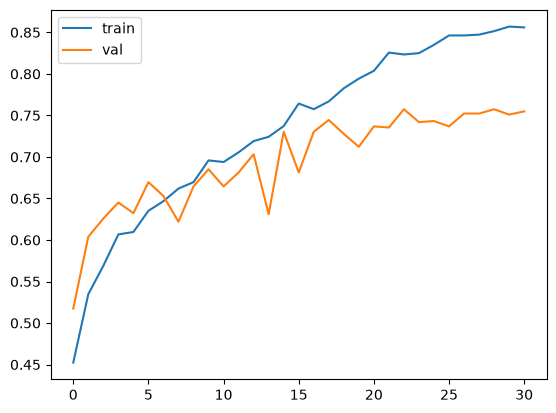

In [58]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.show()

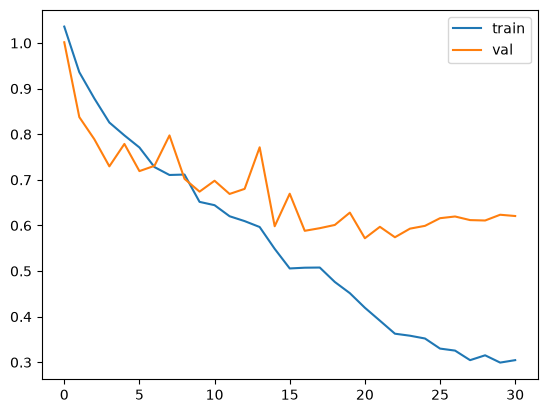

In [59]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])
plt.show()

In [60]:
model.save("sentiment_model.h5")
joblib.dump(tokenizer, 'tokenizer.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

['label_encoder.pkl']

In [61]:
def predict_sentiment(text):
    cleaned = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    pred = model.predict(padded, verbose=0)
    label_idx = pred.argmax(axis=1)[0]
    confidence = pred[0][label_idx]
    label = label_encoder.inverse_transform([label_idx])[0]
    print(f"Text      : {text}")
    print(f"Prediction: {label}  (confidence: {confidence:.2%})")
    return label
 
# Test examples
print("\n--- Inference Tests ---")
predict_sentiment("Tesla stock rises after record profits")
predict_sentiment("Company faces massive losses due to fraud")
predict_sentiment("Markets remain stable amid global uncertainty")


--- Inference Tests ---
Text      : Tesla stock rises after record profits
Prediction: positive  (confidence: 95.06%)
Text      : Company faces massive losses due to fraud
Prediction: negative  (confidence: 97.83%)
Text      : Markets remain stable amid global uncertainty
Prediction: negative  (confidence: 41.75%)


'negative'